In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

In [ ]:

np.random.seed(42)
n = 200

TV = np.random.uniform(0.1, 300, n)
Radio = np.random.uniform(0.1, 50, n)
Social_Media = np.random.uniform(0.1, 30, n)
Sales = 2.5 + 0.045*TV + 0.19*Radio + 0.12*Social_Media + np.random.normal(0, 1.5, n)

df = pd.DataFrame({'TV': TV, 'Radio': Radio, 'Social_Media': Social_Media, 'Sales': Sales})
print(df.shape)
df.head()

(200, 4)


,TV,Radio,Social_Media,Sales
0,112.424582,32.137379,3.183404,13.251830
1,285.219220,4.298584,27.086332,18.212647
2,219.624983,8.165273,15.207046,15.598826
3,179.637679,44.937854,24.811078,20.546354
4,46.889990,30.360810,9.669483,10.708467


               TV       Radio  Social_Media       Sales
count  200.000000  200.000000    200.000000  200.000000
mean   145.253469   25.268319     15.668116   15.628316
std     88.437940   14.620759      9.188533    4.977823
min      1.756083    0.352573      0.424046    2.366087
25%     68.651866   13.146979      7.740057   11.708574
50%    148.396427   27.127830     15.809444   15.834320
75%    227.082199   37.135746     24.352335   19.284070
max    296.067392   49.526207     29.991558   25.639877

Missing values:
 TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


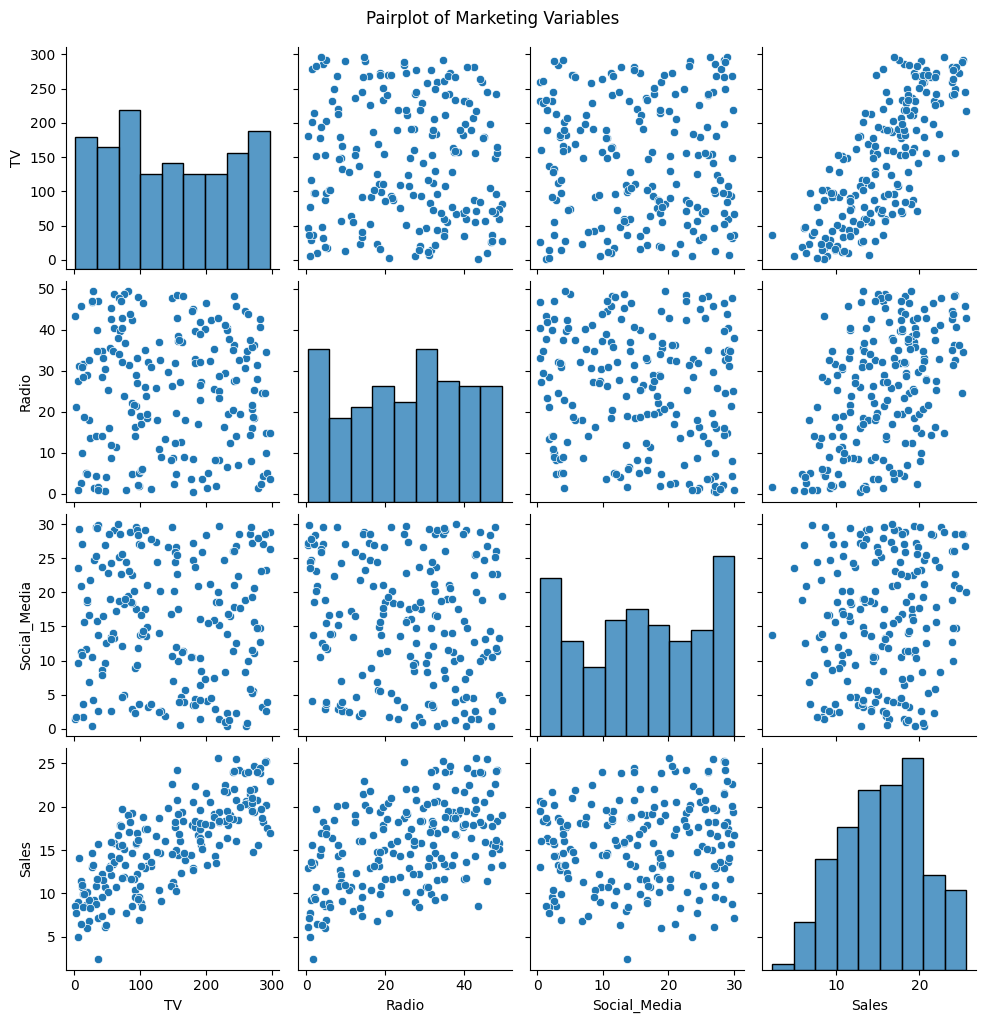

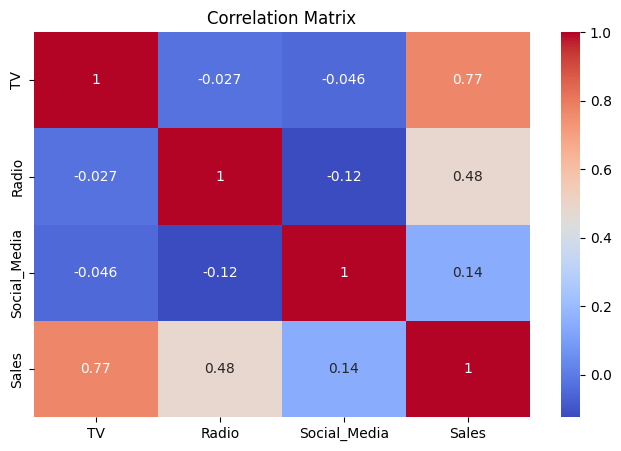

In [ ]:
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

sns.pairplot(df)
plt.suptitle("Pairplot of Marketing Variables", y=1.02)
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:

correlations = df.corr()['Sales'].drop('Sales')
print("Correlations with Sales:\n", correlations)
best_predictor = correlations.idxmax()
print(f"\nBest predictor: {best_predictor}")

Correlations with Sales:
 TV              0.769659
Radio           0.483763
Social_Media    0.144257
Name: Sales, dtype: float64

Best predictor: TV


In [ ]:

X = df['TV']
y = df['Sales']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     287.7
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.91e-40
Time:                        10:14:41   Log-Likelihood:                -514.54
No. Observations:                 200   AIC:                             1033.
Df Residuals:                     198   BIC:                             1040.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3358      0.434     21.510      0.0

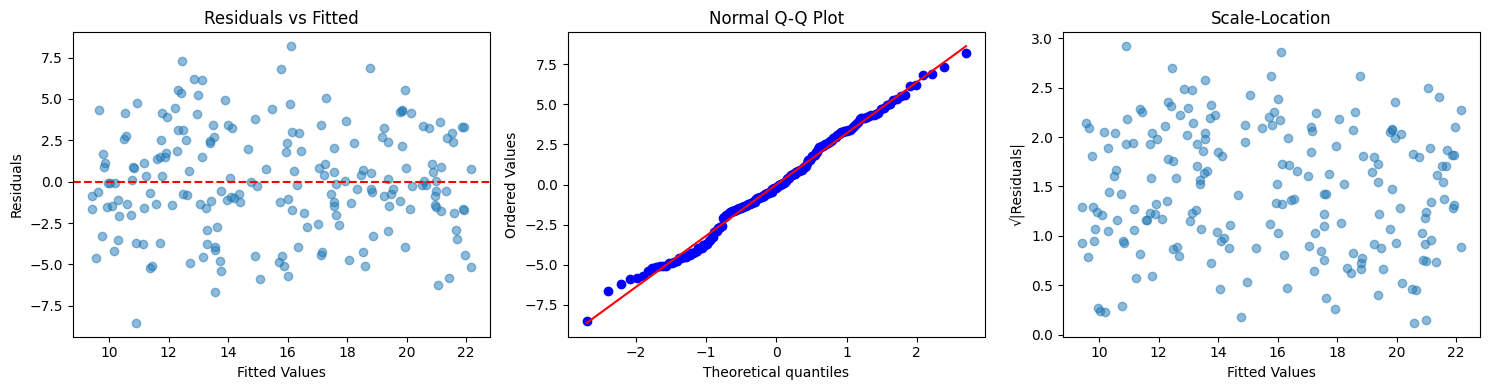

In [ ]:

fitted = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Linearity
axes[0].scatter(fitted, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")

# Normality
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")

# Homoscedasticity
axes[2].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5)
axes[2].set_title("Scale-Location")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("√|Residuals|")

plt.tight_layout()
plt.show()

In [ ]:
r2 = model.rsquared
coef_TV = model.params['TV']
pval_TV = model.pvalues['TV']

print("=" * 50)
print("MODEL INTERPRETATION")
print("=" * 50)
print(f"R-squared: {r2:.4f}")
print(f"TV Coefficient: {coef_TV:.4f}")
print(f"P-value (TV): {pval_TV:.6f}")

print("""
BUSINESS RECOMMENDATION:
- TV advertising has the strongest correlation with Sales.
- Every $1 increase in TV budget increases Sales by {:.4f} units.
- R² of {:.2%} means TV explains {:.2%} of Sales variance.
- P-value < 0.05 confirms TV is statistically significant.
- Recommendation: Prioritize TV budget allocation for maximum ROI.
""".format(coef_TV, r2, r2))

MODEL INTERPRETATION
R-squared: 0.5924
TV Coefficient: 0.0433
P-value (TV): 0.000000

BUSINESS RECOMMENDATION:
- TV advertising has the strongest correlation with Sales.
- Every $1 increase in TV budget increases Sales by 0.0433 units.
- R² of 59.24% means TV explains 59.24% of Sales variance.
- P-value < 0.05 confirms TV is statistically significant.
- Recommendation: Prioritize TV budget allocation for maximum ROI.

